# Tarea 4
## Ejercicio 1

### Tlacaelel Jaime Flores Villaseñor

# Imports

In [9]:
import numpy as np
import os
from pathlib import Path
import hnswlib
import gc
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import IncrementalPCA
import matplotlib.pyplot as plt

# Carga de descriptores SIFT

In [10]:

def load_sift_descriptors(folder_path: str, split: str):
    """
    Carga descriptores SIFT organizados train  y test.
    """
    base_path = Path(folder_path) / split
    X = []  # Lista para almacenar matrices de descriptores por imagen
    y = []  # Etiquetas numéricas
    
    # Obtener nombres de las clases (carpetas dentro de train/test)
    classes = sorted([d.name for d in base_path.iterdir() if d.is_dir()])
    class_to_idx = {name: i for i, name in enumerate(classes)}
    
    print(f"Cargando partición: {split}")
    
    for class_name in classes:
        
        features_dir = base_path / class_name / "features"
        
        if not features_dir.exists():
            print(f"Advertencia: No se encontró la carpeta features en {class_name}")
            continue
            
        # Iterar sobre los archivos .npy
        for npy_file in features_dir.glob("*.npy"):
            # Los descriptores SIFT son de 128 dimensiones
            descriptors = np.load(npy_file).astype(np.float32)
            X.append(descriptors)
            y.append(class_to_idx[class_name])
            
    return X, np.array(y), class_to_idx
            

In [11]:
X_train, y_train, mapping = load_sift_descriptors("data_tarea", "train")
X_test, y_test, _ = load_sift_descriptors("data_tarea", "test")

Cargando partición: train
Cargando partición: test


Tenemos  clases con 100 imagenes cada una en la carpeta de train, por lo que el tamaño de X train debe ser $15 \times 100 = 1500$

In [12]:
len(X_train)


1500

In [13]:
len(y_train)

1500

In [14]:
mapping

{'bedroom': 0,
 'coast': 1,
 'forest': 2,
 'highway': 3,
 'industrial': 4,
 'insidecity': 5,
 'kitchen': 6,
 'livingroom': 7,
 'mountain': 8,
 'office': 9,
 'opencountry': 10,
 'store': 11,
 'street': 12,
 'suburb': 13,
 'tallbuilding': 14}

In [15]:
def build_visual_vocabulary(data, k=10000, iterations=5):
    """
    Implementación de K-Means con HNSW.
    """
    n_samples, dim = data.shape
    
    print(f"Inicializando {k} centroides...")
    initial_indices = np.random.choice(n_samples, k, replace=False)
    centroids = data[initial_indices].copy()
    
    for i in range(iterations):
        print(f"Iteración {i+1}/{iterations} iniciada...")
        
        # Configuración del índice HNSW para los centroides
        # M: número de conexiones bidireccionales
        # ef_construction: tiempo/precisión en la construcción
        index = hnswlib.Index(space='l2', dim=dim)
        index.init_index(max_elements=k, ef_construction=200, M=16)
        index.add_items(centroids)
        index.set_ef(50) # Precisión en la búsqueda
        
        # Buscar el centroide más cercano para cada punto de data
        # labels: (n_samples, 1), contiene el índice del centroide asignado
        labels, _ = index.knn_query(data, k=1)
        labels = labels.flatten()
        
        # Mover los centroides al promedio de sus puntos asignados
        new_centroids = np.zeros_like(centroids)
        counts = np.zeros(k)
        
        # Vectorización parcial para calcular promedios
        for j in range(k):
            mask = (labels == j)
            if np.any(mask):
                new_centroids[j] = data[mask].mean(axis=0)
            else:
                # Si un centroide queda huérfano, se re-inicializa con un punto aleatorio
                new_centroids[j] = data[np.random.randint(n_samples)]
        
        centroids = new_centroids
        
        # Limpieza de memoria del índice en cada iteración
        del index
        gc.collect()
        
    return centroids

In [16]:
# Ejecución con la matriz concatenada de entrenamiento
X_train_stacked = np.vstack(X_train).astype(np.float32)
visual_vocabulary = build_visual_vocabulary(X_train_stacked)

Inicializando 10000 centroides...
Iteración 1/5 iniciada...
Iteración 2/5 iniciada...
Iteración 3/5 iniciada...
Iteración 4/5 iniciada...
Iteración 5/5 iniciada...


Guardar el vocabulario

In [17]:
np.save("visual_vocabulary_10k.npy", visual_vocabulary)

In [18]:
# LIBERAR MEMORIA
del X_train_stacked
gc.collect()


0

# Cuantización de Descriptores

definimos una función que transforme la lista de descriptores de cada imagen en un histograma de frecuencias.

In [19]:
# Leer el vocabulario visual desde el archivo guardado
visual_vocabulary = np.load("visual_vocabulary_10k.npy")

In [20]:
def compute_bof_histograms(X_list, vocabulary, k=10000):
    """
    Transforma listas de descriptores en histogramas de palabras visuales.
    """
    dim = vocabulary.shape[1]
    
    # Configurar índice HNSW para búsqueda rápida de vecinos
    index = hnswlib.Index(space='l2', dim=dim)
    index.init_index(max_elements=k, ef_construction=200, M=16)
    index.add_items(vocabulary)
    index.set_ef(50)
    
    histograms = []
    
    print(f"Procesando {len(X_list)} imágenes...")
    for descriptors in X_list:
        # Encontrar el centroide más cercano para cada descriptor de la imagen
        labels, _ = index.knn_query(descriptors.astype(np.float32), k=1)
        
        # Construir el histograma de frecuencias minlength asegura que el histograma siempre tenga tamaño 10,000
        counts = np.bincount(labels.flatten(), minlength=k)
        histograms.append(counts)
        
    return np.array(histograms, dtype=np.float32)

# Ejecución para ambos conjuntos
bof_train_raw = compute_bof_histograms(X_train, visual_vocabulary)
bof_test_raw = compute_bof_histograms(X_test, visual_vocabulary)

Procesando 1500 imágenes...
Procesando 2985 imágenes...


los histogramas deben ponderarse mediante tf-idf y normalizarse.  La ponderación $tf-idf$ para una palabra visual $w$ en una imagen $d$ se define como:$$tf\text{-}idf(w, d) = tf(w, d) \times \log\left(\frac{N}{df(w)}\right)$$
Donde $N$ es el número total de imágenes y $df(w)$ es el número de imágenes que contienen la palabra $w$.  

In [21]:
tfidf = TfidfTransformer(norm='l2', use_idf=True)

# Ajustar el transformador SOLO con los datos de entrenamiento
bof_train = tfidf.fit_transform(bof_train_raw).toarray()

# Aplicar a los datos de prueba
bof_test = tfidf.transform(bof_test_raw).toarray()

print(f"Forma final de la matriz de entrenamiento: {bof_train.shape}")

Forma final de la matriz de entrenamiento: (1500, 10000)


In [22]:
np.save("bof_train_final.npy", bof_train)
np.save("bof_test_final.npy", bof_test)

# Análisis para Descriptores SIFT

## Función para Reducir Descriptores SIFT
Esta función reduce la dimensionalidad intrínseca de los puntos de interés.

In [23]:
def reduce_sift_features(X_stacked, n_components, batch_size=2048)-> tuple[np.ndarray, IncrementalPCA]:
    """
    Reduce descriptores SIFT de 128 a n_components.
    Utiliza IncrementalPCA para manejar grandes volúmenes de datos sin cargar todo en memoria.
    Argumentos:
        - X_stacked: Matriz apilada de descriptores SIFT (n_samples, 128)
        - n_components: Número de componentes principales a conservar
        - batch_size: Tamaño del lote para el ajuste incremental
    Returns:
        - X_reduced: Matriz de descriptores reducidos (n_samples, n_components)
        - ipca: Modelo IncrementalPCA ajustado
    """
    ipca = IncrementalPCA(n_components=n_components)
    
    # Ajuste por lotes
    for i in range(0, X_stacked.shape[0], batch_size):
        ipca.partial_fit(X_stacked[i:i + batch_size])
        
    # Transformación
    X_reduced = ipca.transform(X_stacked)
    return X_reduced, ipca

## Función para Reducir Bolsas de Características


In [24]:
def reduce_bof_representation(bof_matrix, n_components, batch_size=200)-> tuple[np.ndarray, IncrementalPCA]:
    """
    Reduce histogramas de 10,000 a n_components.
    Utiliza IncrementalPCA para manejar grandes volúmenes de datos sin cargar todo en memoria.
    Argumentos:
        - bof_matrix: Matriz de histogramas BoF (n_samples, 10000)
        - n_components: Número de componentes principales a conservar
        - batch_size: Tamaño del lote para el ajuste incremental
    Returns:
        - bof_reduced: Matriz de histogramas reducidos (n_samples, n_components)
        - ipca: Modelo IncrementalPCA ajustado
    """
    ipca = IncrementalPCA(n_components=n_components)
    
    # Ajuste por lotes
    for i in range(0, bof_matrix.shape[0], batch_size):
        ipca.partial_fit(bof_matrix[i:i + batch_size])
        
    # Transformación
    bof_reduced = ipca.transform(bof_matrix)
    return bof_reduced, ipca

## Exploración de Varianza

In [32]:
def explorar_pca(data, nombre_dato, max_components, batch_size=500):
    """
    Grafica la varianza explicada acumulada para ayudar a la selección manual.
    """
    # Ajustar n_components al mínimo entre lo deseado y las dimensiones del dato
    n_comp = min(max_components, data.shape[1], data.shape[0])
    ipca = IncrementalPCA(n_components=n_comp)
    
    # partial_fit para eficiencia en memoria
    for i in range(0, data.shape[0], batch_size):
        ipca.partial_fit(data[i:i + batch_size])
    
    varianza_acumulada = np.cumsum(ipca.explained_variance_ratio_)

    # Encontrar el índice exacto para el 95%
    m_95 = np.argmax(varianza_acumulada >= 0.95) + 1

    # Encontrar el índice exacto para el 90%
    m_90 = np.argmax(varianza_acumulada >= 0.90) + 1

    print(f"Número exacto para 95% de varianza: {m_95}")
        
    # Graficación
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 'b-')
    plt.axhline(y=0.95, color='r', linestyle='--', label='95% Varianza')
    plt.axhline(y=0.90, color='g', linestyle='--', label='90% Varianza')
    
    plt.title(f"Análisis de Varianza Explicada: {nombre_dato}")
    plt.xlabel("Número de Componentes")
    plt.ylabel("Varianza Acumulada")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return varianza_acumulada

Número exacto para 95% de varianza: 1319


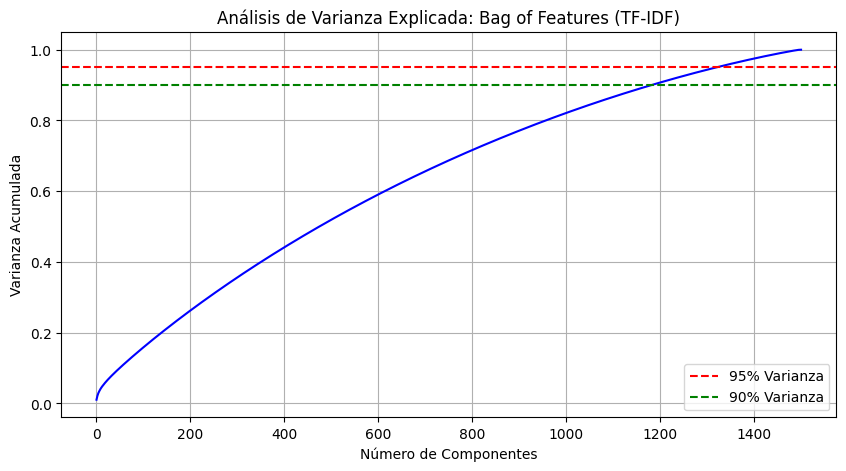

In [33]:
# Cargar las bolsas de entrenamiento
bof_train = np.load("bof_train_final.npy")

# Explorar los primeros 1000 componentes de las 10,000 dimensiones originales
varianza_bof = explorar_pca(bof_train, "Bag of Features (TF-IDF)", max_components=1499, batch_size=1500)

Número exacto para 95% de varianza: 74


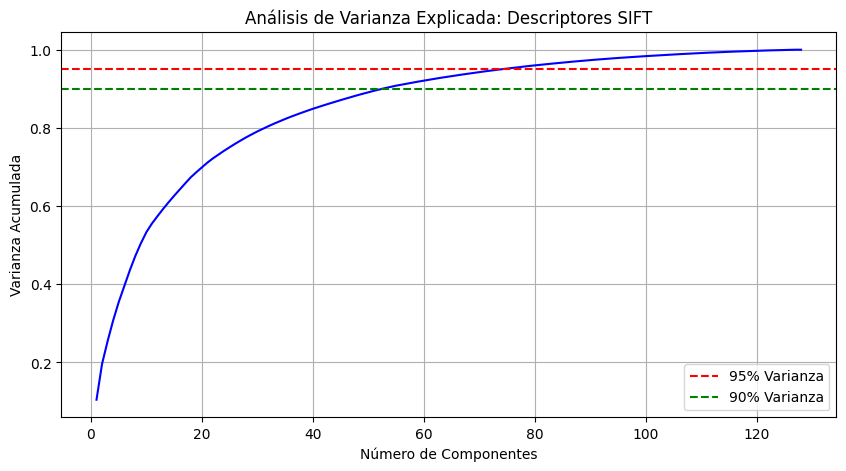

In [34]:
# Re-generar matriz de SIFT solo para el análisis de PCA
X_sift_temp = np.vstack(X_train).astype(np.float32)

# Explorar hasta los 128 componentes originales
varianza_sift = explorar_pca(X_sift_temp, "Descriptores SIFT", max_components=128)
